# Улучшение baseline-модели

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv, find_dotenv
from os import environ
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy.engine.base import Engine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, PolynomialFeatures, KBinsDiscretizer,
    FunctionTransformer
)
from category_encoders import CatBoostEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    median_absolute_error
)
import seaborn as sns
import plotly.express as px
from autofeat import AutoFeatRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from typing import Optional, List, Union
from sklearn.impute import SimpleImputer
import time
import joblib
import os
import json

## Этап 2: Исследовательский Анализ Данных (EDA)

### 2.1. Загрузка данных

Загрузка параметров конфигурации для подключения к БД:

In [2]:
load_dotenv(find_dotenv())

True

In [3]:
DB_USER = environ['DB_USER']
DB_HOST = environ['DB_HOST']
DB_PORT = environ['DB_PORT']
DB_NAME = environ['DB_NAME']
DB_PASSWORD = environ['DB_PASSWORD']

Подключение к БД

In [4]:
db_conn_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

In [5]:
conn = create_engine(db_conn_url)

Загрузка данных:

In [6]:
sql = "select * from buildings_flats"

In [7]:
data = pd.read_sql(sql, conn)

Закрываем подключение к БД:

In [8]:
conn.dispose()

### 2.2. Общий обзор датасета

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100928 entries, 0 to 100927
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   building_id        100928 non-null  int64  
 1   flat_id            100928 non-null  int64  
 2   build_year         100928 non-null  int64  
 3   building_type_int  100928 non-null  int64  
 4   latitude           100928 non-null  float64
 5   longitude          100928 non-null  float64
 6   ceiling_height     100928 non-null  float64
 7   flats_count        100928 non-null  int64  
 8   floors_total       100928 non-null  int64  
 9   has_elevator       100928 non-null  bool   
 10  floor              100928 non-null  int64  
 11  kitchen_area       100928 non-null  float64
 12  living_area        100928 non-null  float64
 13  rooms              100928 non-null  int64  
 14  is_apartment       100928 non-null  bool   
 15  studio             100928 non-null  bool   
 16  to

Настройка параметров отображения для работы с большими данными:

In [10]:
pd.options.display.max_columns = 100
pd.options.display.max_rows = 64 

Основные статистические характеристики числовых данных:

In [11]:
data.describe()

,building_id,flat_id,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,floor,kitchen_area,living_area,rooms,total_area,price
count,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,100928.000000,1.009280e+05
mean,13235.552344,71595.130202,1984.260621,3.532449,55.730954,37.597841,2.686337,242.093562,13.084090,6.763227,8.646471,30.936057,1.949816,51.883511,1.183833e+07
std,6358.539275,41424.026863,19.208103,1.402605,0.107924,0.157480,0.129421,169.010672,5.080863,4.508283,2.280058,11.544195,0.818618,16.237297,4.532862e+06
min,4.000000,0.000000,1902.000000,0.000000,55.211460,36.864372,2.400000,1.000000,1.000000,1.000000,4.000000,8.000000,1.000000,16.000000,3.000000e+06
25%,8336.000000,33718.250000,1969.000000,4.000000,55.648075,37.494484,2.640000,112.000000,9.000000,3.000000,6.500000,20.000000,1.000000,38.500000,8.500000e+06
50%,12985.000000,73257.000000,1980.000000,4.000000,55.718594,37.590549,2.640000,201.000000,12.000000,6.000000,8.600000,30.000000,2.000000,49.000000,1.080000e+07
75%,18433.000000,106921.250000,2002.000000,4.000000,55.817533,37.720547,2.700000,320.000000,17.000000,10.000000,10.000000,38.900002,3.000000,60.799999,1.400000e+07
max,24620.000000,141361.000000,2023.000000,6.000000,56.011032,37.946411,3.000000,4455.000000,29.000000,20.000000,16.500000,75.000000,5.000000,121.000000,2.900000e+07


Количество пропусков:

In [12]:
data.isnull().sum().sort_values(ascending=False)

building_id          0
flat_id              0
build_year           0
building_type_int    0
latitude             0
longitude            0
ceiling_height       0
flats_count          0
floors_total         0
has_elevator         0
floor                0
kitchen_area         0
living_area          0
rooms                0
is_apartment         0
studio               0
total_area           0
price                0
dtype: int64

<u>**Анализ**</u>

**Выброс в flats_count**: Значение 4455 нужно ограничить, например, на уровне 99-го перцентиля.

**Кодировка типа здания**: `building_type_int` можно преобразовать в категориальный тип (Categorical / Object), чтобы модель не пыталась искать линейную зависимость между "типом 1" и "типом 6".

**Пропуски**: Явных пропусков нет.

### 2.3. Анализ признаков для модели

#### Числовые признаки

In [13]:
def histplot(df: pd.DataFrame, col: str):
    fig, axes = plt.subplots(figsize=(6, 4))

    sns.histplot(data[col], bins=60, kde=True, ax=axes, color='steelblue')
    axes.set_title(f'{col}\nskew={data[col].skew():.2f}')
    axes.set_xlabel('')
    
    plt.tight_layout()
    plt.show()

##### Год постройки

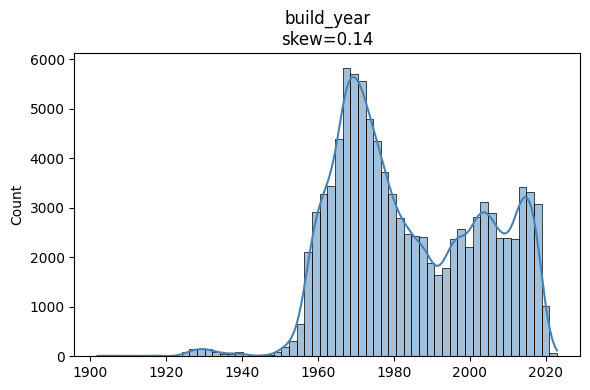

In [14]:
histplot(data, 'build_year')

<u>**Анализ**</u>

Бимодальная форма распределения с двумя выраженными модами — около 1970 г. и 2010–2015 гг.

Skew = 0.14: распределение близко к симметричному, но с лёгким хвостом в сторону новых построек.

**Вывод**: Массовая советская застройка 1960–80-х доминирует в выборке, за ней следует волна нового строительства 2000–2010-х. Также есть небольшое количество объектов 1930–1940-х годов (сталинская застройка). В военное и поствоенное время (1940е года) лотов практически нет.

##### Широта и долгота

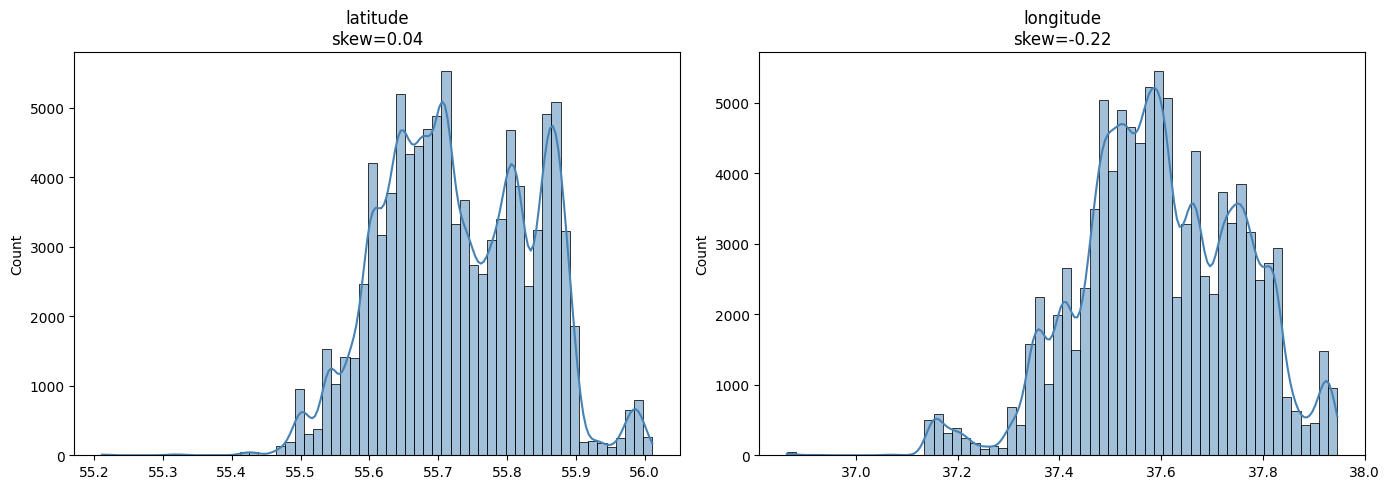

In [15]:
ll_cols = ['latitude', 'longitude']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

for i, col in enumerate(ll_cols):
    sns.histplot(data[col], bins=60, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}\nskew={data[col].skew():.2f}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Географическое распределение объектов')

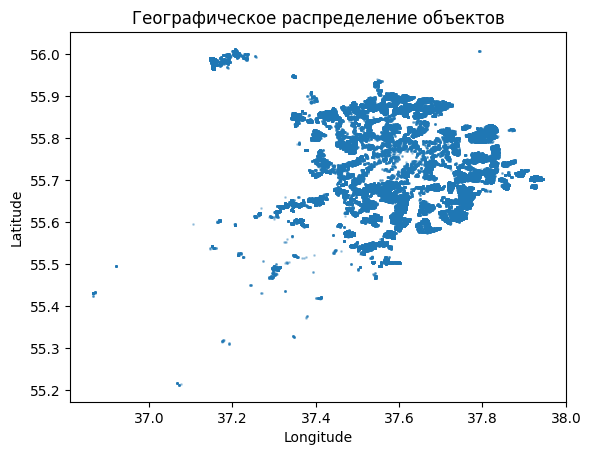

In [16]:
plt.scatter(data['longitude'], data['latitude'], alpha=0.3, s=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Географическое распределение объектов')

<u>**Анализ**</u>

**Широта**

Мультимодальное распределение с 3 выраженными пиками: основной пик ~55.7, второй пик ~55.87, третий пик ~55.98.

Skew ~ 0: распределение практически симметрмчное. Данные равномерно покрывают город с севера на юг.

Выражен разрыв между широтой 55.9 и 56.0.

**Долгота**

Мультимодальное распределение с небольшим левым перекосом.

Skew=-0.22: слабая ассиментрия, большинство значений сосредоточены в правой части распределения (на западе).

**Географическое распределение объектов**

Scatter-plot подтверждает кластерную структуру данных, выявленную на гистограммах. Распределение объектов явно соответствует географии Москвы и Московской области.

Основное скопление продаваемых объектов находится на территории Москвы и ближайших пригородов. Отдельной выделяются объекты за территорией "основной" Москвы (скорее всего, это территория Зеленограда). 

Заметны лоты далеко за пределами Москвы (Подмосковье дальше Зеленограда), которые можно считать выбросами.

**Вывод**: Географические признаки имеют кластерную структуру, соответствующую административному делению Москвы. Зеленоград является отдельным округом, и, возможно, будет лучше исключить его из выборки.

##### Высота потолков

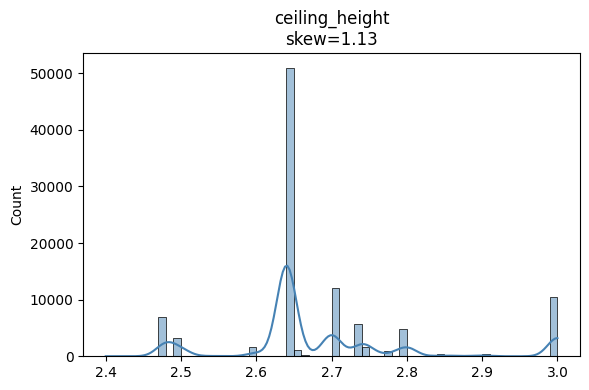

In [17]:
histplot(data, 'ceiling_height')

<u>**Анализ**</u>

Распределение не является непрерывным. Каждый пик относится к конкретному типу застройки.

Skew=1.13: сильная правосторонняя ассиметрия - хвост в сторону высоких потолков 3 м.

**Вывод**: нельзя использовать, как числовой признак. Отпимально использовать категоризацию, что превратит дискретный числовой признак в категории, отражающие реальную структуру данных:
* 0 - 2.55;
* 2.56 - 2.7;
* 2.71 - 2.8;
* 2.81+

##### Количество квартир в доме

In [ ]:
histplot(data, 'flats_count')

<u>**Анализ**</u>

Логарифмически нормальное распределение с несколькими пиками: 1й пик ~0-100 квартир, 2й пик ~100-200 квартир, 3й пик ~200-500 квартир.

Skew=1.74: очень сильная правосторонняя симетрия - хвост в сторону огромных домов с колличеством квартир более 1000.

Наблюдаются дома с малым количеством квартир (около 1), что является выбросами (возможно, частные дома).

**Вывод**: Подавляющее большинство объектов в выборке имеют небольшое количество квартир — до 500 единиц. Длинный правый хвост свидетельствует о наличии выбросов — объектов с аномально высоким числом flats (1000+), что может соответствовать крупным жилым комплексам. Также присутствуют выбросы слевой стороны - малоквартирные дома.

##### Количество этажей

In [ ]:
histplot(data, 'floors_total')

<u>**Анализ**</u>

Распределение не является непрерывным. Каждый пик соответствует типичным этажностям жилых зданий: 5, 9, 12, 18.

Skew = 0.29: распределение близко к симметричному с лёгким правосторонним хвостом. Основная масса данных сосредоточена в диапазоне 5-20 этажей.

**Вывод**: нельзя использовать, как числовой признак. Отпимально использовать категоризацию: 
* малоэтажные 1-5;
* срежнеэтажные 6-12;
* высокоэтажные 13-20;
* небоскребы 21+.

##### Этаж

In [ ]:
histplot(data, 'floor')

<u>**Анализ**</u>

Убывающее «ступенчатое» распределение. Количество наблюдений монотонно уменьшается с ростом номера этажа, но делает это неравномерно, образуя выраженные плато.

Skew = 0.72: Умеренная правосторонняя асимметрия. Хвост распределения вытянут в сторону высоких этажей, что логично, так как высоких домов в выборке меньше.

**Вывод:** Распределение этажа квартиры (floor) является прямым следствием распределения этажности зданий (floors_total), рассмотренного ранее. Абсолютный номер этажа может быть неинформативен для модели, чем относительное положение, например, бинарные признаки "первый этаж", "последний этаж".

##### Количество комнат

In [ ]:
histplot(data, 'rooms')

<u>**Анализ**</u>

Дискретная мультимодальная форма распределения с четко выраженными пиками на целых значениях количества комнат.

Skew = 0.37: небольшая положительная асимметрия, распределение смещено в сторону меньшего количества комнат. Основная масса данных сосредоточена в диапазоне 1-3 комнаты.

**Вывод**: Распределение отражает типичную структуру жилого фонда с преобладанием 1-3 комнатных квартир. Двухкомнатные квартиры доминируют в выборке, что соответствует стандартному спросу на рынке недвижимости. 

##### Площадь

In [ ]:
histplot(data, 'total_area')

area_cols = ['living_area', 'kitchen_area']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

for i, col in enumerate(area_cols):
    sns.histplot(data[col], bins=60, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}\nskew={data[col].skew():.2f}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

<u>**Анализ**</u>

Все три признака демонстрируют правостороннюю асимметрию.

**Общая площадь**

Мультимодальное распределение с несколькими локальными максимумами, что может указывать на разные типы квартир (студии, 1-комнатные, 2-комнатные и т.д.).

Skew = 0.90: умеренная правосторонняя асимметрия. Основная часть объектов - небольшие квартиры для 80 кв.м. Хвост в правую сторону (квартиры более 80 кв.м.).

**Жилая площадь**

Мультимодальное распределения с 3 выраженными пиками: ~20, ~30 и ~45.

Skew = 0.76: умеренная правосторонняя симетрия.

Распределение жилой площади аналогично распределению общей площади: 3 пика слева на право, хвост в правой части.

**Площадь кухни**

Наиболее выраженная мультимодальность, вероятные группы: маленькие кухни (6 кв.м), средние (8-10 кв.м), большие (12+ кв.м).

Skew = 0.61: умеренная правосторонняя ассиметрия (наименьшая асимметрия среди трех).

**Вывод**: 
* Мультимодальность указывает на возможность сегментации данных по типам квартир.
* Вероятна высокая корреляция между total_area и living_area.

#### Бинарные признаки

In [ ]:
def countplot(df: pd.DataFrame, col: str):
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.countplot(x=df[col], hue=df[col], ax=ax, palette='Set2')
    ax.set_title(f'{col} (доля True = {df[col].mean():.2%})')
    
    plt.tight_layout()
    plt.show()

##### Наличие лифта

In [ ]:
countplot(data, 'has_elevator')

<u>**Анализ**</u>

Признак сильно несбалансирован.

* True (Есть лифт): 89.62% данных.
* False (Нет лифта): 10.38% данных.

Поскольку 90% данных — это True, модель может просто выучить правило: "Лифт есть почти всегда". Если в тестовой выборке попадется квартира без лифта, модель может ошибиться, если не учтет этаж.

**Вывод**: Наличие лифта — это важный ценообразующий фактор, но его влияние нелинейно и сильно зависит от типа здания. Следуюет проанализировать корреляцию с этажностью здания и типом дома.

##### Апартаменты

In [ ]:
countplot(data, 'is_apartment')

<u>**Анализ**</u>

Экстремальный дисбаланс классов:

* False (Не апартаменты): 99.61% объектов.
* True (Апартаменты): 0.39% объектов.

Признак почти константен. Если после разделения на train/test в тестовой выборке не окажется ни одного объекта True, признак станет бесполезным.

**Вывод**: Признак `is_apartment` непригоден для использования в модели в текущем виде из-за экстремального дисбаланса. Следует исключить апартаменты из датасета или объединить с другими типами недвижимости, например, со студиями.

##### Студии

In [ ]:
countplot(data, 'studio')

<u>**Анализ**</u>

Признак константен, в выборке нет ни одного объекта-студии.

**Вывод**: Признак `studio` в текущем виде абсолютно бесполезен и должен быть удален.

#### Категориальные признаки

##### Тип дома

In [ ]:
building_type_int_col = 'building_type_int'

fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(x=data[building_type_int_col], hue=data[building_type_int_col], ax=ax, palette='Set2')
ax.set_title(building_type_int_col)

plt.tight_layout()
plt.show()

In [ ]:
percent = (
    data['building_type_int']
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .astype(str) + ' %'
)
percent

<u>**Анализ**</u>

Распределение:

* 4 — 66.49% (Доминирующий класс): Более 2/3 всех объектов. Скорее всего, это самый распространенный тип жилья (например, "Панельный").
* 1 — 14.4%: Второй по популярности тип.
* 6 — 9.16%: Третий тип.
* 2 — 8.61%: Четвертый тип.
* 0 — 1.1%: Редкий тип (миноритарный).
* 3 — 0.24% (Практически отсутствует): Очень редкий тип, почти как в предыдущем примере со студиями.

Отсутствует значение 5. Это может означать, что тип 5 был удален как выброс, или в данных его просто нет.

Класс 3 (0.24%) и класс 0 (1.1%) — это миноритарные классы. Если оставить их как есть, модель может их проигнорировать или переобучиться на них (если они окажутся выбросами по цене). Возможно объединить редкие классы или удалить их.

**Вывод**: Признак `building_type_int` скорее всего будет коррелировать с целевой переменной, но для дальнейшего применения требуется дополнительная обработка.

### 2.4. Анализ целевой переменной

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Гистограмма
sns.histplot(data['price'], bins=80, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение price')
axes[0].set_xlabel('price')

# Boxplot
sns.boxplot(x=data['price'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot price')
axes[1].set_xlabel('price')

plt.tight_layout()
plt.show()

Скошенность и эксцесс:

In [ ]:
print("Skew:", data['price'].skew())
print("Kurtosis:", data['price'].kurt())

In [ ]:
data['price'].describe()

<u>**Анализ**</u>

**1. Распределение**

Skew=1.16: выраженная правосторонняя ассиметрия.

Сильное правостороннее смещение. Основная масса данных сосредоточена в диапазоне 5-15 млн, но есть длинный хвост вправо до 29 млн. Пик частоты около 10 млн.

Такое распределение не является нормальным, что может негативно влиять на работу многих статистических моделей, но для CatBoost такое распределение не является критичной проблемой.

**2. Выбросы**

На boxplot видны выбросы за пределами верхнего уса. Максимальное значение 29 млн почти в 2 раза превышает Q3 (14 млн).

**3. Эксцесс**

Kurtosis=1.3: Положительный эксцесс -> распределение островершинное, с более тяжёлыми хвостами, чем у нормального. Это усиливает влияние выбросов на модель.

**Вывод**: Целевая переменная price имеет выраженную правостороннюю асимметрию и тяжёлые хвосты. Стоит применить логарифмическое преобразование, чтобы выровнять распределение, снизить влияние выбросов и улучшить качество предсказаний.

##### Распределение log

In [ ]:
fig, axes = plt.subplots(figsize=(6, 4))

sns.histplot(data['price'], bins=80, kde=True, ax=axes, color='seagreen')
axes.set_xscale('log')
axes.set_title('Распределение price (log X)')
axes.set_xlabel('price (log)')

plt.tight_layout()
plt.show()

<u>**Анализ**</u>

Логарифмическое преобразование успешно улучшило распределение целевой переменной:

* Распределение стало ближе к нормальному
* Логарифмическое преобразование успешно сжало правый хвост.

### 2.5. Анализ целевой переменной в зависимости от различных признаков

#### Матрица корреляций

In [ ]:
plt.figure(figsize=(14, 10))

corr_df = data.drop(["building_id", "flat_id", "studio"], axis=1)

corr = corr_df.corr(numeric_only=True)

sns.heatmap(
    corr, 
    annot=True, 
    fmt='.2f',
    cmap='coolwarm', 
    center=0, 
    square=True,
    linewidths=0.5, 
    cbar_kws={'shrink': 0.8}
)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

### 2.6. Выводы после EDA

#### 1. Пропуски и бесполезные признаки

В данных нет явных пропусков.

Признак `studio` неинформативен, так как не содержит ни одного объекта `True`.

Признак `is_apartment` имеет экстремальный дисбаланс классов (99.6% False), что делает его практически бесполезным для модели.

Следует удалить признаки `studio` и `is_apartment`.

#### 2. Признаки

Обнаружены выбросы по признакам `latitude` и `longitude`: некоторые объекты находятся далеко за пределами Москвы.

Числовые признаки с нелинейной зависимостью: `ceiling_height`, `floors_total`, `build_year` имеют мультимодальное распределение. Их использование как чисел может быть неоптимальным. `flats_count` имеет сильную правостороннюю асимметрию и выбросы.

Для `ceiling_height`, `floors_total` можно рассмотреть создание категориальных признаков на основе анализа, что может помочь модели. 

#### 3.Целевая переменная (price):

Распределение сильно асимметрично (skew=1.16) с длинным правым хвостом.

Чтобы приблизить распределение к нормальному и повысить качество модели можно применить логарифмическое преобразование np.log1p(price) к целевой переменной во время обучения

#### 4. Корреляции и мультиколлинеарность:

Сильная связь целевой переменной со следующими признаками: `total_area`, `living_area`, `rooms`.

Мультиколлинеарность: `living_area` и `rooms` очень сильно коррелируют с `total_area` (0.94 и 0.85 соответственно). Также `floors_total` коррелирует с `build_year` и `has_elevator`.

Для упрощения модели и снижения шума можно удалить `living_area` и `rooms`, оставив `total_area` как наиболее информативный признак. Это уменьшит размерность и может ускорить обучение без существенной потери качества. 

Признаки `floor` и `floors_total` можно удалить, заменив на бинарные признаки `is_first_floor` и `is_last_floor`.

Признаки `latitude` и `longitude` имеют очень слабую линейную корреляцию с ценой, но их распределение показывает четкую кластерную структуру. Можно попробовать заменить их на признак, показывающий удаленность объекта от центра.

#### Итоговый план

1. Очистить выбросы по комбинации признаков `latitude` и `longitude`.
2. Разбить признак `ceiling_height` на категории.
3. Удалить признаки `studio` по причине неинформативности.
4. Удалить избыточные признаки `living_area` и `rooms` по причине высокой корреляции с `total_area`.
5. Удалить признак `floor`, заменив на бинарные признаки `is_first_floor` и `is_last_floor`.
6. Удалить признаки `latitude` и `longitude`, заменив на расстояние от центра.
7. Удалить признаки `has_elevator`, `is_apartment`, `flats_count`, `build_year`, т.к. они плохо коррелируют с целевой переменной.

### 2.6. Выводы после EDA

#### 1. Пропуски и неинформативные признаки
* **Пропуски**: Явные пропуски в данных отсутствуют.
* **Константные и несбалансированные признаки**: 
  - Признак `studio` неинформативен, так как не содержит ни одного значения `True`.
  - Признак `is_apartment` имеет экстремальный дисбаланс классов (99.6% значений `False`), что делает его бесполезным для обучения модели.
    **Решение**: Оба признака подлежат удалению.

#### 2. Пространственные признаки и выбросы
* В признаках `latitude` и `longitude` обнаружены выбросы: часть объектов находится далеко за пределами Москвы.
* Линейная корреляция сырых координат с ценой очень слабая, однако визуальный анализ показывает четкую кластерную структуру (географическую зависимость цены).
  **Решение**: Отфильтровать явные выбросы за пределами целевого региона. Заменить сырые координаты на инженерный признак `distance_to_center` (расстояние до центра Москвы), который лучше capture-ит нелинейную географическую зависимость.

#### 3. Числовые признаки и их распределения
* Признаки `ceiling_height`, `floors_total` и `build_year` имеют мультимодальное (дискретное) распределение. Использование их как непрерывных числовых признаков может быть неоптимальным.
* Признак `flats_count` имеет сильную правостороннюю асимметрию и значительные выбросы.
  **Решение**: Для `ceiling_height` целесообразно создать категориальный признак (например, "низкие", "стандартные", "высокие" потолки). 

#### 4. Целевая переменная (`price`)
* Распределение цены сильно асимметрично (skew = 1.16) и имеет длинный правый хвост, что характерно для данных о недвижимости.
 **Решение**: Применить логарифмическое преобразование `np.log1p(price)` на этапе обучения модели. Это приблизит распределение к нормальному, стабилизирует дисперсию и повысит качество метрик (например, RMSLE).

#### 5. Корреляции и мультиколлинеарность
* **Связь с целевой переменной**: Наблюдается сильная положительная связь `price` с признаками `total_area`, `living_area` и `rooms`.
* **Мультиколлинеарность**: 
  - `living_area` и `rooms` очень сильно коррелируют с `total_area` (0.94 и 0.85 соответственно).
  - `floors_total` коррелирует с `build_year` и `has_elevator`.
    **Решение**: Для снижения шума и мультиколлинеарности удалить `living_area` и `rooms`, оставив `total_area` как наиболее стабильный и информативный интегральный признак площади. 

---

### Итоговый план предобработки данных (Feature Engineering Pipeline)

1. **Фильтрация выбросов**: Удалить объекты, чьи координаты (`latitude`, `longitude`) выходят за разумные географические границы Москвы и ближайшего Подмосковья.
2. **Удаление мусорных признаков**: Удалить `studio` и `is_apartment` из-за отсутствия вариативности и экстремального дисбаланса.
3. **Инженерия признаков этажности**: На основе пары `floor` и `floors_total` создать два бинарных признака: `is_first_floor` и `is_last_floor`. После этого оригинальные признаки `floor` и `floors_total` удалить.
4. **Инженерия гео-признаков**: Рассчитать признак `distance_to_center` (расстояние до центра по формуле Haversine). Удалить исходные `latitude` и `longitude`.
5. **Борьба с мультиколлинеарностью**: Удалить признаки `living_area` и `rooms`, оставив только `total_area`.
6. **Категоризация**: Преобразовать непрерывный признак `ceiling_height` в категориальный (например, с помощью биннинга: < 2.7 м, 2.7–3.0 м, > 3.0 м).
7. **Удаление слабых признаков**: Удалить `build_year`, `has_elevator` и `flats_count` в связи со слабой корреляцией с целевой переменной, наличием выбросов и дублированием информации (например, год постройки и наличие лифта косвенно уже учтены в других признаках или не дают прироста качества).
8. **Преобразование цели**: Применить `np.log1p` к целевой переменной `price` перед обучением модели (с обратным преобразованием `np.expm1` для получения предсказаний в исходных единицах).

### 2.7. Логирование артефактов в MLflow

Артефакты: 
* `model_improvement/EDA.ipynb` - Jupyter Notebook с проведенным EDA;
* `model_improvement/EDA_conclusion.md` - Markdown-файл с выводами по проведенному EDA.

Для логирования артефактов был доработан скрипт регистрации модели: `mlflow_server/scripts/mlflow_register.py`.

**Результат**:

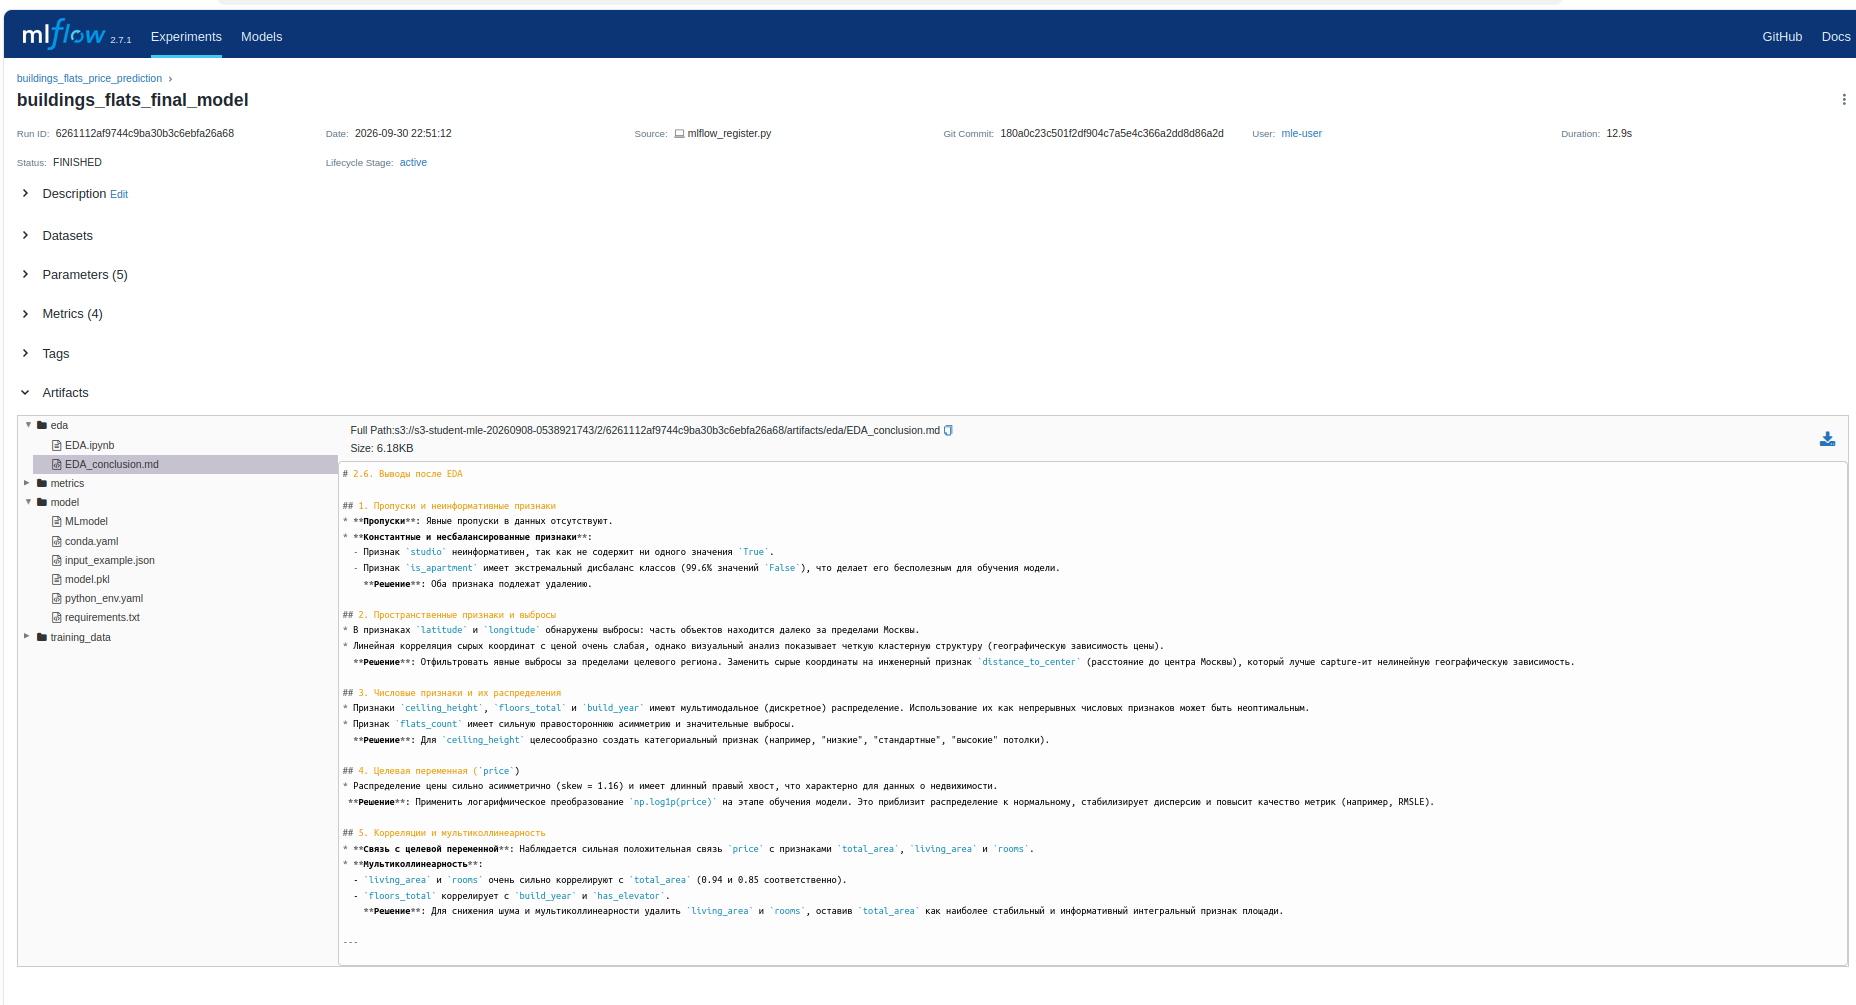

## Этап 3. Генерация Признаков и Обучение Новой Версии Модели

### 3.1. Ручная генерация признаков

Фильтрация выбросов по координатам (Москва и ближайшее Подмосковье). Из общедоступных источников известно, что Москва располагается между 55.2 и 56.1 градусами с.ш. и 37.03 и 37.9 в.д.:

In [ ]:
filtered_data = data[
    (data['latitude'] > 55.2) & (data['latitude'] < 56.1) &
    (data['longitude'] > 37.03) & (data['longitude'] < 37.9)
].copy()

Признаки этажности:

In [ ]:
filtered_data['is_first_floor'] = (filtered_data['floor'] == 1).astype(int)
filtered_data['is_last_floor'] = (filtered_data['floor'] == filtered_data['floors_total']).astype(int)

Расстояние до центра Москвы. Из общедостпных источников известно, что центр Москвы имеет следующие широту и долготу: 55.45 с.ш. и 37.37 в.д.:

In [ ]:
def calc_distance(lat1, lon1, lat2=55.45, lon2=37.37):
    """Расстояние от центра в км по формуле Haversine"""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [ ]:
filtered_data['distance_to_center'] = calc_distance(filtered_data['latitude'], filtered_data['longitude'])

Формирование списка признаков:

In [ ]:
drop_cols = [
    'studio', 
    'is_apartment',        
    'living_area', 
    'rooms', 
    'floor', 
    'floors_total',
    'latitude', 
    'longitude', 
    'build_year', 
    'has_elevator', 
    'flats_count',
    'building_id', 
    'flat_id',
    'price'
]

In [ ]:
feature_cols = [col for col in filtered_data.columns if col not in drop_cols]
X = filtered_data[feature_cols].copy()

In [ ]:
X

Целевая переменная (применяем логарифмирование):

In [ ]:
y = np.log1p(filtered_data['price'])

Разделение на train/test:

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### 3.2. Оборачивание всех преобразований в объекты sklear

Числовые признаки:

In [ ]:
numeric_features = ['total_area', 'kitchen_area', 'distance_to_center']

Признаки для дискретизации:

In [ ]:
binned_features = ['distance_to_center', 'ceiling_height']

Категориальные признаки:

In [ ]:
categorical_features = ['building_type_int']

Трансформер для числовых признаков:

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False))
])

Трансформер для дискретизации:
* стратегия `quantile` создает бины с одинаковым количеством наблюдейни, что дает устойчивость к выбросам;
* 5 зон примерно соответствуют: центр, ТТК, средняя зона, МКАД, Москва за МКАДом.

In [ ]:
bin_transformer = KBinsDiscretizer(
    n_bins=5, 
    encode='onehot-dense', 
    strategy='quantile'
)

Трансформер для категориальных признаков:

In [ ]:
cat_transformer = OneHotEncoder(drop='if_binary', sparse_output=False)

ColumnTransformer:

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', bin_transformer, binned_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='passthrough'
)

Sklearn-пайплайн:

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

### 3.3. Автоматическая генерация признаков

Генератор признаков:

In [ ]:
autofeat = AutoFeatRegressor(
    feateng_steps=2, 
    verbose=1,
    n_jobs=1
)

Добавим генератор признаков в ColumnTransformer:

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('autofeat', autofeat, numeric_features),
        ('bin', bin_transformer, binned_features),
        ('cat', cat_transformer, categorical_features)
    ],
    remainder='passthrough'
)

Обновим пайплайн:

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

### 3.4. Обучение новой версии модели

#### Обучение

In [ ]:
fit_start_time = time.time()
pipeline.fit(X_tr, y_tr)
fit_end_time = time.time()

#### Метрики

Время обучения:

In [ ]:
training_time = fit_end_time - fit_start_time
training_time

In [ ]:
pred_start_time = time.time()
y_pred = pipeline.predict(X_val)
end_time = time.time()

Время предсказания:

In [ ]:
prediction_time = end_time - pred_start_time
prediction_time

Обратное преобразование предсказаний и истинных значений из логарифмов в рубли:

In [ ]:
y_val_real = np.expm1(y_val)
y_pred_real = np.expm1(y_pred)

In [ ]:
mae = mean_absolute_error(y_val_real, y_pred_real)
print(f'MAE: {mae:.2f} руб')

In [ ]:
mape = mean_absolute_percentage_error(y_val_real, y_pred_real) * 100
print(f'MAPE: {mape:.2f}%')

In [ ]:
r2 = r2_score(y_val_real, y_pred_real)
print(f'R^2: {r2:.2f}')

#### Сохранение новой версии модели:

Сохранение пайплайна:

In [ ]:
ARTIFACT_DIR = 'artifacts_v2'

In [ ]:
joblib.dump(pipeline, os.path.join(ARTIFACT_DIR, 'pipeline.joblib'))

Сохранение обучающих данных:

In [ ]:
X_tr.to_csv(os.path.join(ARTIFACT_DIR, 'X_tr.csv'), index=False)
y_tr.to_csv(os.path.join(ARTIFACT_DIR, 'y_tr_real.csv'), index=False, header=['price'])

Сохранение тестовых данных:

In [ ]:
X_val.to_csv(os.path.join(ARTIFACT_DIR, 'X_val.csv'), index=False)
y_val_real.to_csv(os.path.join(ARTIFACT_DIR, 'y_val_real.csv'), index=False, header=['price'])

Сохранение метрик:

In [ ]:
metrics = {
    'mae': mae,
    'mape': mape,
    'r2': r2,
    'training_time': training_time,
    'prediction_time': prediction_time
}

In [ ]:
with open(os.path.join(ARTIFACT_DIR, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)

### 3.5. Выводы после обучения новой версии модели

**Сводная таблица метрик:**

| Метрика | Базовая модель (learn_baseline.ipynb) | Новая модель (EDA.ipynb) | Изменение |
|---|---|---|---|
| MAE | 1 863 224,51 руб | 2 106 081,78 руб | Ухудшение |
| MAPE | 16,68% | 18,13% | Ухудшение |
| R² | 0,73 | 0,63 | Ухудшение |

Средняя абсолютная ошибка в рублях выросла на ~243 тыс. руб. Это означает, что в среднем новая модель ошибается сильнее, чем базовая.

Средняя относительная ошибка также увеличилась. Теперь модель в среднем ошибается на 18.13% от реальной цены, что хуже, чем 16.68% у базовой модели.

Доля объясненной дисперсии целевой переменной снизилась с 73% до 63%. Это наиболее значимое ухудшение, которое говорит о том, что новая модель стала хуже описывать зависимость цены от признаков.

Несмотря на проделанную работу по Feature Engineering, новая модель показала результаты хуже базовой. Наиболее вероятные причины:

* Было удалено много признаков, которые, возможно, были важны для модели, несмотря на низкую линейную корреляцию с целевой переменной. 
* Логарифмирование целевой переменной могло привести к ухудшению метрик в исходном масштабе.
* Возможно, часть созданных признаков оказалась "шумом" или вредной информацией. Например, distance_to_center — полезный признак, но его дискретизация на 5 бакетов могла быть неоптимальной.

**Производительность модели:** 

Время обучения

Время обучения составляет около 2 минут. Это обусловлено тем, что в пайплайн включен блок автоматической генерации признаков, который тратит время на перебор комбинаций, фильтрацию корреляций и отбор признаков. После этого происходит обучение CatBoostRegressor на 1000 итераций. Для этапа исследования и переобучения это абсолютно нормальное и приемлемое время.

Время предсказания

Предсказание на валидационной выборке происходит практически мгновенно. Это отличный показатель для продакшена. Модель может обрабатывать запросы в реальном времени без задержек, заметных для пользователя.

**Вывод: Базовая модель оказалась лучше.**

Несмотря на интуитивно правильные шаги по улучшению, новая версия модели не оправдала ожиданий. Все ключевые метрики ухудшились.